# Semantic Alignment Score (SAS) - Calibration

This notebook implements the calibration phase of the SAS (Semantic Alignment Score). It validates the three score variants (SAS-corr, SAS-dep, SAS-loc) by comparing them with a real IoU against ground truth masks (PASCAL VOC validation set), using an external pretrained ViT model (DINO), and not the LeJEPA/supervised models trained for the project.

**Steps:**

1. Loads pretrained DINO ViT-S/16 via Torch Hub.
2. Loads PASCAL VOC 2012 (validation split, 1449 images).
3. For each image, it computes: (i) saliency map (self-attention CLS->patch of the last block), (ii) PCA mask on the patch tokens, (iii) the three SAS metrics between the two maps, and (iv) the real IoU between the saliency map and the ground truth mask.
4. Spearman correlation to each SAS variant with the real IoU -> selects the variant to use for LeJEPA models.
5. Runs the two null tests: (i) random weights (control model), (ii) randomly paired images (control bias), and (iii) spatial patch-shuffling (control for spatial correspondence).
6. Computes bootstrap confidence intervals on the correlations.


## 1. Imports

### 1.1 Install packages

In [ ]:
!pip install -q dcor

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 4.1 MB/s eta 0:00:00


### 1.2 Import libraries

In [ ]:
import os
from pathlib import Path
import json
import random
import numpy as np
import pandas as pd
import torch
import torchvision
from torchvision import transforms
from torchvision.datasets import VOCSegmentation
from sklearn.decomposition import PCA
from sklearn.metrics import jaccard_score
from scipy.stats import spearmanr
from scipy.stats import bootstrap
import matplotlib.pyplot as plt
import dcor
from tqdm.auto import tqdm
from torch.nn.init import trunc_normal_
import warnings
warnings.filterwarnings('ignore') # for dcor

### 1.3 Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Globals

In [ ]:
SEED = 42

# pretrained DINO architecture torch hub facebookresearch/dino.
# vits16 = ViT-Small, patch 16x16 -> 14x14 grid at 224px
ARCH = "dino_vits16"
PATCH_SIZE = 16
IMG_SIZE = 224
GRID_SIZE = IMG_SIZE // PATCH_SIZE  # grid size of patches (14x14)

VOC_ROOT = "./data"
VOC_YEAR = "2012"
VOC_SPLIT = "val" # validation split

N_CALIBRATION_IMAGES = None # None = entire dataset; else a 'int' for a quick test

MASS_THRESHOLDS = [0.4, 0.5, 0.6, 0.7, 0.8] # fraction of mass retained (from DINO)

# boostrap for statistical test
# resampling with replacement over images
N_BOOTSTRAP = 2000

# device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# save path
SAVE_PATH = "/content/drive/MyDrive/CV_project/outputs/sas_comparison"
os.makedirs(SAVE_PATH, exist_ok=True)
SAVE_PATH = Path(SAVE_PATH)

print(f"Architecture: {ARCH}")
print(f"Device: {DEVICE}")

Architecture: dino_vits16
Device: cuda


## 3. Utils

### 3.1 Seed for reproducibility

In [ ]:
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print(f"Seed: {SEED}")

Seed: 42


### 3.2 Helper Functions


##### PCA sign convention
PC1 of the patch embedding has an arbitrary sign -> we needed to decide which side represents the foreground.

Two approaches were tried:
1. *Minority-region heuristic*: assume foreground occupies fewer patches the background.
2. *Topological anchor by maximum degree*: `argmax` of the patch-similarity-graph degree.
3. **Current approach**: `argmin` of the degree.

The (1) and (2) were abandoned because:
1. It is a dataset-dependent: on PASCAL VOC the main subject frequently occupies more than half of a coarse 14x14 grid, making the approach be inverse more often (mean `sas_corr` was strongly negative, -0.09).
2. The foreground patch is the one with the lowest mutual similarity to the rest of the image (background tends to be redundant) (mean `sas_corr` dropped to -0.51).

In [ ]:
def load_dino_model(arch=ARCH):
    """
    Loads the official pretrained DINO model via Torch Hub
    """
    model = torch.hub.load("facebookresearch/dino:main", arch)
    model.eval()
    model.to(DEVICE)
    return model

@torch.no_grad()
def extract_attention_dino(model, img_tensor):
    """Attention of the last layer"""
    attn = model.get_last_selfattention(img_tensor.unsqueeze(0).to(DEVICE))
    return attn[0].cpu().numpy()   # [n_heads, n_tokens, n_tokens]

@torch.no_grad()
def extract_patch_tokens_dino(model, img_tensor):
    """Patch token of the last layer"""
    feats = model.get_intermediate_layers(img_tensor.unsqueeze(0).to(DEVICE), n=1)[0]
    return feats[0, 1:, :].cpu().numpy()   # [n_patches, embed_dim], no CLS


@torch.no_grad()
def get_attention_saliency(model, img_tensor, attention_extractor=extract_attention_dino):
    """
    Label-free saliency: self-attention CLS -> patch of the last block,
    averaged across heads
    Returns 2D maps:
    raw: softmax raw -> for sas_loc and iou_vs_ground_truth
    norm: softmax normalized min-max in [0,1] -> for sas_corr and sas_dep
    """
    attn = attention_extractor(model, img_tensor)  # [n_heads, n_tokens, n_tokens]
    cls_attn = attn[:, 0, 1:] # CLS -> patch, [n_heads, n_patches]
    cls_attn = cls_attn.mean(axis=0)  # mean, [n_patches]

    # actual softmax attention weights used for mass-based thresholding
    raw = cls_attn.reshape(GRID_SIZE, GRID_SIZE)

    # min-max rescaled
    norm = (raw - raw.min()) / (raw.max() - raw.min() + 1e-12)  # min-max
    return raw, norm


@torch.no_grad()
def get_patch_tokens(model, img_tensor, token_extractor=extract_patch_tokens_dino):
    """
    Extracts the patch tokens from the last layer (excluding CLS)
    """
    return token_extractor(model, img_tensor)


def get_pca_map(patch_tokens):
    """
    PCA map, see note above for the sign convention
    """
    norm_tokens = patch_tokens / (np.linalg.norm(patch_tokens, axis=1, keepdims=True) + 1e-12)
    similarity_matrix = np.dot(norm_tokens, norm_tokens.T) # [196, 196]
    degrees = similarity_matrix.sum(axis=1) # [196]
    foreground_anchor_idx = np.argmin(degrees) # foreground

    # PCA
    pca = PCA(n_components=1)
    component = pca.fit_transform(patch_tokens).reshape(-1) # [196]
    explained_variance = pca.explained_variance_ratio_[0]

    # pca sign
    sign_flipped = bool(component[foreground_anchor_idx] < component.mean())
    if sign_flipped:
        component = -component

    grid = component.reshape(GRID_SIZE, GRID_SIZE)
    grid = (grid - grid.min()) / (grid.max() - grid.min() + 1e-12)
    return grid, explained_variance, sign_flipped


def threshold_by_mass(map2d, tau):
    """
    Thresholding "by mass" (from DINO): sorts values in
    descending order and retains pixels that sum up to tau of the total mass
    """
    flat = map2d.flatten()
    order = np.argsort(flat)[::-1]
    cumsum = np.cumsum(flat[order])
    total = cumsum[-1] if cumsum[-1] > 0 else 1e-12
    cutoff_idx = np.searchsorted(cumsum, tau * total)
    mask = np.zeros_like(flat, dtype=bool)
    mask[order[:cutoff_idx + 1]] = True
    return mask.reshape(map2d.shape)


def compute_iou(mask_a, mask_b):
    """IoU between two binary masks"""
    return jaccard_score(mask_a.flatten(), mask_b.flatten(), zero_division=0)


def reset_model_weights(model):
    """
    Reinitializes module parameters in-place for the null test
    """
    # reset standard: Linear, LayerNorm ...
    for module in model.modules():
        if hasattr(module, "reset_parameters"):
            module.reset_parameters()

    # reset vit specific parameters
    if hasattr(model, "pos_embed") and model.pos_embed is not None:
        trunc_normal_(model.pos_embed, std=0.02)
    if hasattr(model, "cls_token") and model.cls_token is not None:
        trunc_normal_(model.cls_token, std=0.02)

    return model

In [ ]:
def sas_corr(saliency_map, pca_map):
    """spearman correlation"""
    r, _ = spearmanr(saliency_map.flatten(), pca_map.flatten())
    return r


def sas_dep(saliency_map, pca_map):
    """distance correlation"""
    return dcor.distance_correlation(saliency_map.flatten(), pca_map.flatten())


def sas_loc(saliency_map, pca_map, thresholds=MASS_THRESHOLDS):
    """AUITC, average IoU between the two maps thresholded by mass at different thresholds tau"""
    ious = [compute_iou(threshold_by_mass(saliency_map, t), threshold_by_mass(pca_map, t)) for t in thresholds]
    return float(np.mean(ious))


def iou_vs_ground_truth(saliency_map, gt_mask, thresholds=MASS_THRESHOLDS):
    """
    'Real' IoU: saliency map thresholded by mass vs ground truth mask,
    averaged over the same thresholds used for SAS-loc, making the two numbers directly comparable
    """
    ious = [compute_iou(threshold_by_mass(saliency_map, t), gt_mask) for t in thresholds]
    return float(np.mean(ious))

### 3.3 SAS metrics

Three variants, corresponding to three families (spatial correlation, mutual information, localized overlap).

- **sas_corr**: Spearman rank correlation (inspired by LeJEPA, although it does not use it in this way).
- **sas_dep**: distance correlation, used instead of a histogram based mutual information estimator, because MI is not reliable in limited samples size scenario.
- **sas_loc**: AUITC (Area Under the IoU Threshold Curve). Average IoU between the two maps thresholded by mass. Unlike DINO, it does not rely on a single threshold that must be calibrated.





## 4. Data

### 4.1 Data loading and Preprocessing

Images and masks are both resized to a fixed square so the patch grid and mask grid stay aligned. Masks use NEAREST interpolation because they contain class indices rather than continuous values, any smoothing would create artificial boundary classes that don’t actually exist.

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

preprocess_img = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),   # square: aligns 1:1 with the mask below
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

preprocess_mask = transforms.Resize(
    (IMG_SIZE, IMG_SIZE), interpolation=transforms.InterpolationMode.NEAREST
)  # NEAREST: the mask contains class indices, must not be interpolated

print("Loading PASCAL VOC 2012 validation set...")
voc_dataset = VOCSegmentation(
    root=VOC_ROOT, year=VOC_YEAR, image_set=VOC_SPLIT,
    download=True, transform=preprocess_img, target_transform=preprocess_mask
)
print(f"Dataset loaded: {len(voc_dataset)} images")


def voc_mask_to_fg_bg_patch_grid(mask_pil):
    """
    Converts the VOC mask (0=background, 1-20=classes, 255=border/ignore)
    into a binary foreground/background grid at the resolution of patch tokens
    (GRID_SIZE x GRID_SIZE), consistent with saliency/PCA maps
    Border pixels (255) are excluded from the patch majority vote
    """
    mask = np.array(mask_pil)
    valid = mask != 255
    fg = (mask > 0) & valid

    gh, gw = GRID_SIZE, GRID_SIZE
    ph, pw = mask.shape[0] // gh, mask.shape[1] // gw
    grid = np.zeros((gh, gw), dtype=bool)
    for i in range(gh):
        for j in range(gw):
            patch_fg = fg[i*ph:(i+1)*ph, j*pw:(j+1)*pw]
            patch_valid = valid[i*ph:(i+1)*ph, j*pw:(j+1)*pw]
            if patch_valid.sum() > 0:
                grid[i, j] = (patch_fg.sum() / patch_valid.sum()) > 0.5
    return grid

Loading PASCAL VOC 2012 validation set...


100%|██████████| 2.00G/2.00G [01:24<00:00, 23.6MB/s]


Dataset loaded: 1449 images


### 4.2 Dataset Preview

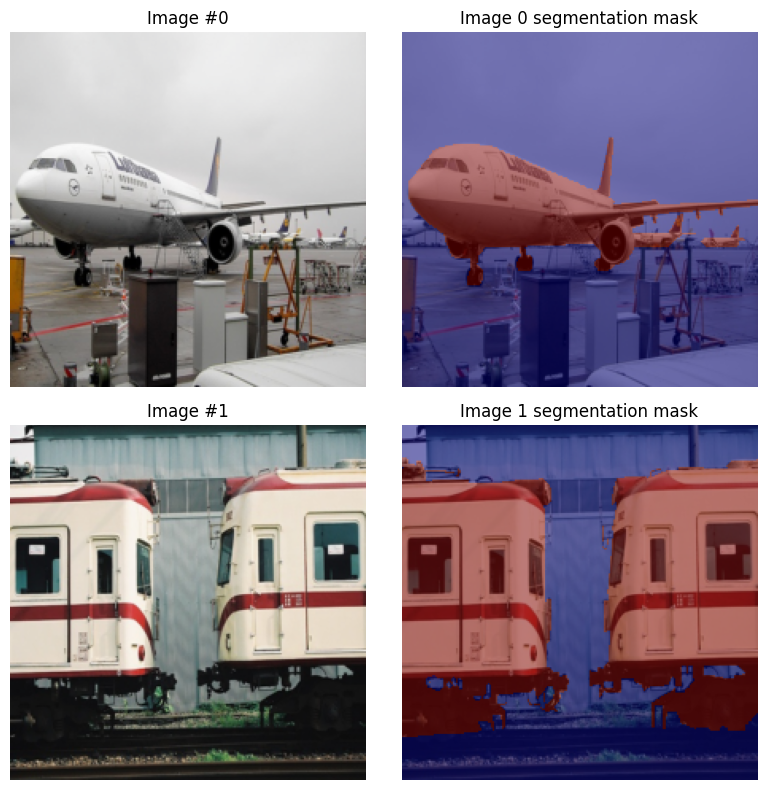

In [ ]:
def denormalize(img_tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    img = img_tensor.clone().cpu().numpy().transpose(1, 2, 0)
    img = img * np.array(std) + np.array(mean)
    return np.clip(img, 0, 1)


N_PREVIEW = 2
fig, axes = plt.subplots(N_PREVIEW, 2, figsize=(8, 4 * N_PREVIEW))
for i in range(N_PREVIEW):
    img_tensor, mask_pil = voc_dataset[i]
    img_np = denormalize(img_tensor)
    mask_np = np.array(mask_pil)
    mask_np = np.where(mask_np == 255, 0, mask_np)  # ignore borders

    axes[i, 0].imshow(img_np)
    axes[i, 0].set_title(f"Image #{i}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(img_np)
    axes[i, 1].imshow(mask_np, cmap="jet", alpha=0.5)
    axes[i, 1].set_title(f"Image {i} segmentation mask")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.savefig(SAVE_PATH / "dataset_preview.png", dpi=150)
plt.show()

## 5. Network

### 5.1 Build the network

DINO ViT-S/16 is used to validate the SAS formulas against real ground truth (Section 6). It is not one of the LeJEPA/supervised models this project ultimately compares; those do not exist yet at the calibration stage. Instead the DINO paper (e.g., Fig. 4) already did a calibration test.

In [ ]:
print(f"Loading pretrained {ARCH} from Torch Hub (facebookresearch/dino)...")
dino_model = load_dino_model(ARCH)

n_params = sum(p.numel() for p in dino_model.parameters())
print(f"Model loaded: {n_params/1e6:.1f}M parameters")

Loading pretrained dino_vits16 from Torch Hub (facebookresearch/dino)...
Downloading: "https://github.com/facebookresearch/dino/zipball/main" to /root/.cache/torch/hub/main.zip
Downloading: "https://dl.fbaipublicfiles.com/dino/dino_deitsmall16_pretrain/dino_deitsmall16_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dino_deitsmall16_pretrain.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 282MB/s]


Model loaded: 21.7M parameters


## 6. Evaluation

### 6.1 Calibration

For each image: saliency map, PCA mask, the three SAS metrics between the two maps, and the real IoU between the saliency map and the ground truth.


In [ ]:
set_seed(SEED)

n_images = len(voc_dataset) if N_CALIBRATION_IMAGES is None else min(N_CALIBRATION_IMAGES, len(voc_dataset))
indices = list(range(len(voc_dataset)))
random.shuffle(indices)
indices = indices[:n_images]

results = []
cached_saliency_raw = []  # for the randomly paired image test
cached_saliency_norm = []
cached_pca = []

for idx in tqdm(indices, desc="Calibration on PASCAL VOC"):
    img_tensor, mask_pil = voc_dataset[idx]

    saliency_raw, saliency_norm = get_attention_saliency(dino_model, img_tensor)
    patch_tokens = get_patch_tokens(dino_model, img_tensor)
    pca_norm, pc1_variance, sign_flipped = get_pca_map(patch_tokens)
    gt_mask = voc_mask_to_fg_bg_patch_grid(mask_pil)
    iou_60 = compute_iou(threshold_by_mass(saliency_raw, 0.6), gt_mask)

    results.append({
        "idx": idx,
        "sas_corr": sas_corr(saliency_norm, pca_norm),
        "sas_dep": sas_dep(saliency_norm, pca_norm),
        "sas_loc": sas_loc(saliency_raw, pca_norm),
        "iou_vs_gt": iou_vs_ground_truth(saliency_raw, gt_mask),
        "pc1_variance": pc1_variance,
        "sign_flipped": sign_flipped,
        "iou_vs_gt_60": iou_60
    })
    cached_saliency_raw.append(saliency_raw)
    cached_saliency_norm.append(saliency_norm)
    cached_pca.append(pca_norm)

# save
df_calibration = pd.DataFrame(results)
df_calibration.to_csv(SAVE_PATH / "sas_calibration_results.csv", index=False)
df_calibration.describe()

Calibration on PASCAL VOC:   0%|          | 0/1449 [00:00<?, ?it/s]

,idx,sas_corr,sas_dep,sas_loc,iou_vs_gt,pc1_variance,iou_vs_gt_60
count,1449.000000,1449.000000,1449.000000,1449.000000,1449.000000,1449.000000,1449.000000
mean,724.000000,0.459021,0.555507,0.334836,0.410833,0.146944,0.435615
std,418.434583,0.381431,0.189762,0.151300,0.164151,0.042129,0.196345
min,0.000000,-0.764663,0.128326,0.026229,0.000000,0.063757,0.000000
25%,362.000000,0.255602,0.396118,0.207619,0.301539,0.116076,0.300000
50%,724.000000,0.582985,0.559767,0.352565,0.439736,0.139492,0.454545
75%,1086.000000,0.745017,0.723595,0.461673,0.544178,0.171106,0.583333
max,1448.000000,0.935776,0.929077,0.699565,0.702206,0.321674,0.921053


#### PC1 Explained Variance

PC1 explained variance ratio - mean: 0.147, std: 0.042, min: 0.064, max: 0.322


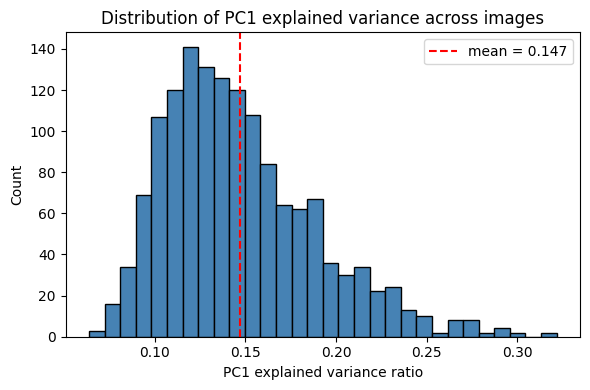

In [ ]:
pc1_stats = df_calibration["pc1_variance"].describe()
print(
    f"PC1 explained variance ratio - "
    f"mean: {pc1_stats['mean']:.3f}, std: {pc1_stats['std']:.3f}, "
    f"min: {pc1_stats['min']:.3f}, max: {pc1_stats['max']:.3f}"
)

plt.figure(figsize=(6, 4))
plt.hist(df_calibration["pc1_variance"], bins=30, color="steelblue", edgecolor="black")
plt.axvline(
    pc1_stats["mean"], color="red", linestyle="--",
    label=f"mean = {pc1_stats['mean']:.3f}"
)
plt.xlabel("PC1 explained variance ratio")
plt.ylabel("Count")
plt.title("Distribution of PC1 explained variance across images")
plt.legend()
plt.tight_layout()
plt.savefig(SAVE_PATH / "pc1_variance_distribution.png", dpi=150)
plt.show()

#### Qualitative Example

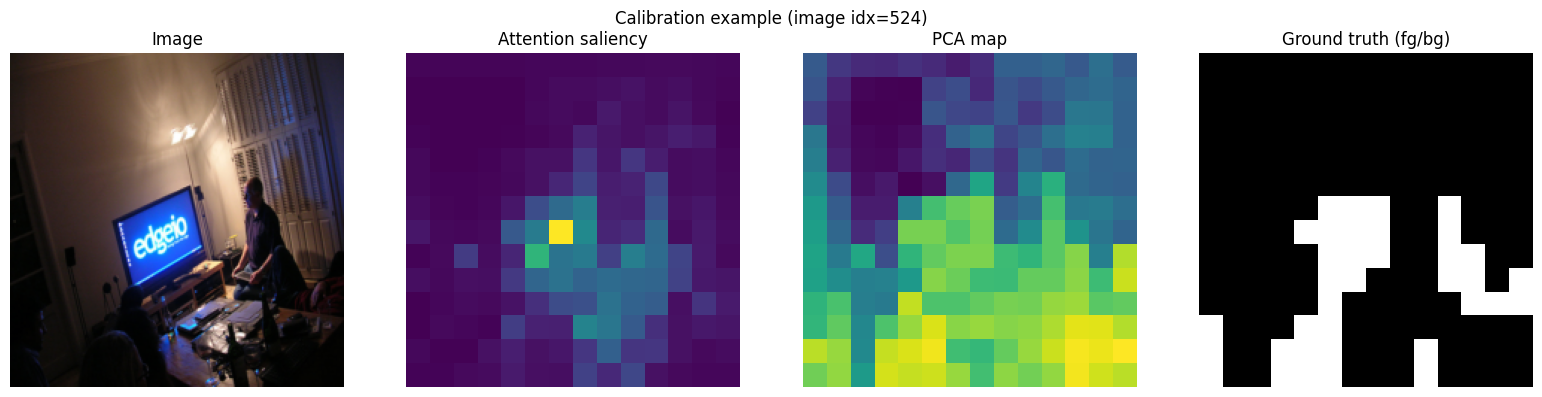

In [ ]:
example_i = 0
example_idx = indices[example_i]
img_tensor, mask_pil = voc_dataset[example_idx]
img_np = denormalize(img_tensor)
gt_mask = voc_mask_to_fg_bg_patch_grid(mask_pil)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(img_np)
axes[0].set_title("Image")
axes[0].axis("off")

axes[1].imshow(cached_saliency_norm[example_i], cmap="viridis")
axes[1].set_title("Attention saliency")
axes[1].axis("off")

axes[2].imshow(cached_pca[example_i], cmap="viridis")
axes[2].set_title("PCA map")
axes[2].axis("off")

axes[3].imshow(gt_mask, cmap="gray")
axes[3].set_title("Ground truth (fg/bg)")
axes[3].axis("off")

plt.suptitle(f"Calibration example (image idx={example_idx})")
plt.tight_layout()
plt.savefig(SAVE_PATH / "calibration_example.png", dpi=150)
plt.show()

### 6.2 Validation: SAS vs IoU-vs-ground-truth Correlation

We want to exclude SAS variant which have a bad spearman correlation with the real IoU.

A variant is marked "reliable" only if its Spearman correlation with `iou_vs_gt` is positive and the bootstrap confidence interval (CI) sits entirely above zero. A single positive point estimate is not enough, given the sign-convention issues encountered earlier.

**Result**: all three variants are reliable after the `argmin` sign fix (`sas_dep` r=0.36, `sas_loc` r=0.25, `sas_corr` r=0.25)

In [ ]:
sas_variants = ["sas_corr", "sas_dep", "sas_loc"]
validation_summary = []


def _spearman_stat(x, y):
    return spearmanr(x, y).correlation


for variant in sas_variants:
    r, p = spearmanr(df_calibration[variant], df_calibration["iou_vs_gt"])

    res = bootstrap(
        (df_calibration[variant].values, df_calibration["iou_vs_gt"].values),
        _spearman_stat, n_resamples=N_BOOTSTRAP, paired=True,
        vectorized=False, method="basic", random_state=SEED
    )

    validation_summary.append({
        "variant": variant,
        "spearman_r": r,
        "p_value": p,
        "ci_low": res.confidence_interval.low,
        "ci_high": res.confidence_interval.high,
    })

# save
df_validation = pd.DataFrame(validation_summary).sort_values("spearman_r", ascending=False)
print(df_validation.to_string(index=False))

df_validation["reliable"] = ((df_validation["spearman_r"] > 0) & (df_validation["ci_low"] > 0))
reliable_variants = df_validation.loc[df_validation["reliable"], "variant"].tolist()
excluded_variants = df_validation.loc[~df_validation["reliable"], "variant"].tolist()
print(df_validation.to_string(index=False))

print(
    f"Variants meeting the reliability criterion (Spearman r > 0 and bootstrap CI entirely above zero):  "
    f"{reliable_variants}"
)

if excluded_variants:
    print(
        f"Excluded variants (correlation with the ground-truth IoU is not reliable): "
        f"{excluded_variants}"
    )

mean_iou = df_calibration["iou_vs_gt"].mean()
print(f"Mean IoU (saliency vs ground truth) on this run: {mean_iou:.3f}")

 variant  spearman_r      p_value   ci_low  ci_high
 sas_dep    0.362166 3.820220e-46 0.318898 0.407659
 sas_loc    0.250292 3.900206e-22 0.201581 0.301032
sas_corr    0.246860 1.473707e-21 0.199804 0.294463
 variant  spearman_r      p_value   ci_low  ci_high  reliable
 sas_dep    0.362166 3.820220e-46 0.318898 0.407659      True
 sas_loc    0.250292 3.900206e-22 0.201581 0.301032      True
sas_corr    0.246860 1.473707e-21 0.199804 0.294463      True
Variants meeting the reliability criterion (Spearman r > 0 and bootstrap CI entirely above zero):  ['sas_dep', 'sas_loc', 'sas_corr']
Mean IoU (saliency vs ground truth) on this run: 0.411


### 6.3 Validation Scatter Plots


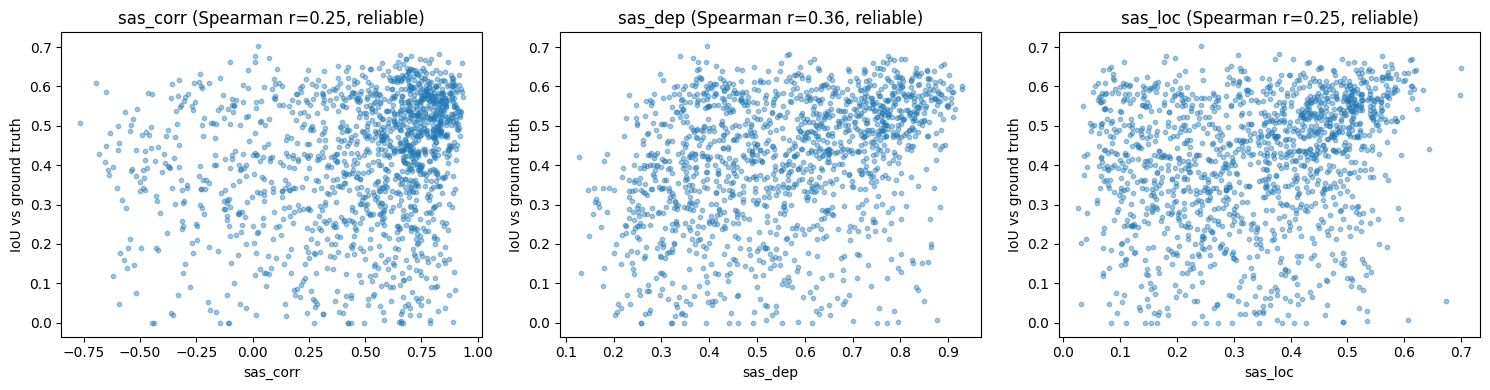

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, variant in zip(axes, sas_variants):
    ax.scatter(df_calibration[variant], df_calibration["iou_vs_gt"], alpha=0.4, s=10)
    ax.set_xlabel(variant)
    ax.set_ylabel("IoU vs ground truth")
    row = df_validation.set_index("variant").loc[variant]
    state = "reliable" if row["reliable"] else "not reliable"
    ax.set_title(f"{variant} (Spearman r={row['spearman_r']:.2f}, {state})")
plt.tight_layout()
plt.savefig(SAVE_PATH / "sas_calibration_scatter.png", dpi=150)
plt.show()

### 6.4 Null Test 1 - Random Weights

A model with no learned structure should not produce a falsely high SAS. This is the one check that did not simply pass once the sign convention was fixed:

- `sas_corr` and `sas_loc` collapse convincingly under random weights (the expected behavior).
- `sas_dep` does not: it stays at or slightly above the trained-model level. Confirmed not to be an artifact of an incomplete weight reset (`pos_embed`/`cls_token` are explicitly re-initialized in `reset_model_weights`, not just standard `nn.Module` parameters) and the effect persists regardless. Confirmed reproducible across four independent random seeds (Section 6.4.3), so treated as a systematic limitation of `sas_dep` rather than a random artifact.

`iou_vs_gt` is also computed here for the random model, as an independent check: it drops substantially (0.41 -> 0.20, similar with the DINO official values), confirming the saliency-vs-ground-truth relationship behaves exactly as expected under this null model.

In [ ]:
set_seed(SEED + 1)

random_model = load_dino_model(ARCH)
random_model = reset_model_weights(random_model)
random_model.eval()

bt_indices = indices
random_results = []

for idx in tqdm(bt_indices, desc="Random weights test"):
    img_tensor, mask_pil = voc_dataset[idx]
    saliency_raw, saliency_norm = get_attention_saliency(random_model, img_tensor)
    patch_tokens = get_patch_tokens(random_model, img_tensor)
    pca_norm, pc1_variance, sign_flipped = get_pca_map(patch_tokens)
    gt_mask = voc_mask_to_fg_bg_patch_grid(mask_pil)
    iou_60 = compute_iou(threshold_by_mass(saliency_raw, 0.6), gt_mask)

    random_results.append({
        "sas_corr": sas_corr(saliency_norm, pca_norm),
        "sas_dep": sas_dep(saliency_norm, pca_norm),
        "sas_loc": sas_loc(saliency_raw, pca_norm),
        "iou_vs_gt": iou_vs_ground_truth(saliency_raw, gt_mask),
        "sign_flipped": sign_flipped,
        "iou_vs_gt_60": iou_60
    })

# save
df_random = pd.DataFrame(random_results)
df_random.to_csv(SAVE_PATH / "sas_null_test1_random_weights.csv", index=False)

print("SAS Comparison - trained model vs random weights:")
comparison_weights = pd.DataFrame({
    "trained_model": df_calibration[sas_variants + ["iou_vs_gt"]].mean(),
    "random_weights": df_random[sas_variants + ["iou_vs_gt"]].mean()
})
print(comparison_weights)
print(f"Random weights: {df_random['iou_vs_gt_60'].mean():.3f}")
print(f"DINO trained: {df_calibration['iou_vs_gt_60'].mean():.3f}")

Using cache found in /root/.cache/torch/hub/facebookresearch_dino_main


Random weights test:   0%|          | 0/1449 [00:00<?, ?it/s]

SAS Comparison - trained model vs random weights:
           trained_model  random_weights
sas_corr        0.459021       -0.343034
sas_dep         0.555507        0.578603
sas_loc         0.334836        0.188633
iou_vs_gt       0.410833        0.199702
Random weights: 0.199
DINO trained: 0.436


#### 6.4.1 Additional test / check

Two extra diagnostics to characterize the `sas_dep` anomaly above, rather than just flag it:

- The per-image distribution of `sas_corr` under random weights is not centered near zero (as pure noise would be) but systematically negative for 79% of images, suggesting a structured artifact tied to this single random weight initialization, rather than unbiased noise.
- The sign-flip frequency of the topological anchor is close to chance (46.5%) under random weights vs. clearly non-chance (30.1%) under trained weights —> confirm that the anchor mechanism captures some structure when trained.

count    1449.000000
mean       -0.343034
std         0.419916
min        -0.971848
25%        -0.660676
50%        -0.470373
75%        -0.109772
max         0.942310
Name: sas_corr, dtype: float64
Fraction of images with negative sas_corr: 79.2%


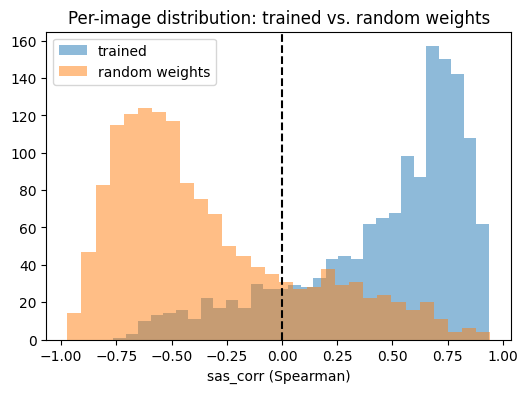

Sign-flip frequency (trained model): 30.1%
Sign-flip frequency (random weights): 46.5%


In [ ]:
# per-image distribution of sas_corr: noise centered around 0 or systematic bias?
print(df_random["sas_corr"].describe())
print(f"Fraction of images with negative sas_corr: {(df_random['sas_corr'] < 0).mean():.1%}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df_calibration["sas_corr"], bins=30, alpha=0.5, label="trained")
ax.hist(df_random["sas_corr"], bins=30, alpha=0.5, label="random weights")
ax.axvline(0, color="k", linestyle="--")
ax.legend()
ax.set_xlabel("sas_corr (Spearman)")
ax.set_title("Per-image distribution: trained vs. random weights")
plt.show()

# frequency of sign flips in the foreground-anchor heuristic
print(f"Sign-flip frequency (trained model): {df_calibration['sign_flipped'].mean():.1%}")
print(f"Sign-flip frequency (random weights): {df_random['sign_flipped'].mean():.1%}")

#### 6.4.2 Qualitative Example

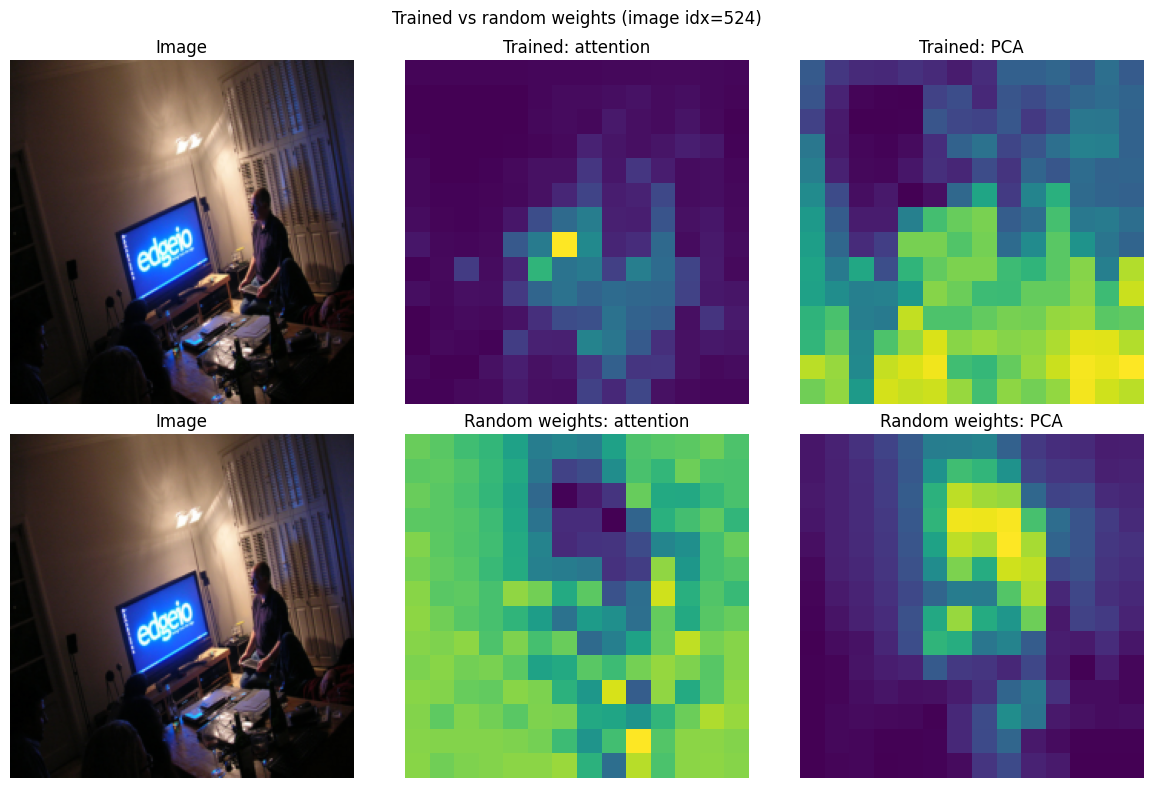

In [ ]:
example_idx = bt_indices[0]
img_tensor, _ = voc_dataset[example_idx]
img_np = denormalize(img_tensor)

# orig model
trained_saliency = cached_saliency_norm[0]
trained_pca = cached_pca[0]

# random weigths model
_, random_saliency_norm = get_attention_saliency(random_model, img_tensor)
random_patch_tokens = get_patch_tokens(random_model, img_tensor)
random_pca_norm, _, _ = get_pca_map(random_patch_tokens)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes[0, 0].imshow(img_np); axes[0, 0].set_title("Image"); axes[0, 0].axis("off")
axes[0, 1].imshow(trained_saliency, cmap="viridis"); axes[0, 1].set_title("Trained: attention"); axes[0, 1].axis("off")
axes[0, 2].imshow(trained_pca, cmap="viridis"); axes[0, 2].set_title("Trained: PCA"); axes[0, 2].axis("off")

axes[1, 0].imshow(img_np); axes[1, 0].set_title("Image"); axes[1, 0].axis("off")
axes[1, 1].imshow(random_saliency_norm, cmap="viridis"); axes[1, 1].set_title("Random weights: attention"); axes[1, 1].axis("off")
axes[1, 2].imshow(random_pca_norm, cmap="viridis"); axes[1, 2].set_title("Random weights: PCA"); axes[1, 2].axis("off")

plt.suptitle(f"Trained vs random weights (image idx={example_idx})")
plt.tight_layout()
plt.savefig(SAVE_PATH / "null_test1_example.png", dpi=150)
plt.show()

#### 6.4.3 Multi-seed robustness check

The test is repeated across multiple seeds because a single random run may not be representative and could be due to chance. This repeats Null Test 1 across four independent random seeds to check whether the `sas_dep` anomaly (Section 6.4) is a property of untrained networks in general or specific to one unlucky draw.

**Result**: `sas_dep` exceeds the trained-model reference on all four seeds without exception, confirming the limitation is systematic.

In [ ]:
N_SEEDS = 4
seed_offsets = [10, 20, 30, 40][:N_SEEDS]

seed_test_indices = indices
multi_seed_results = []

for offset in seed_offsets:
    seed = SEED + offset
    set_seed(seed)

    # new model with random weights
    seed_model = load_dino_model(ARCH)
    seed_model = reset_model_weights(seed_model)
    seed_model.eval()

    per_image = []
    for idx in tqdm(seed_test_indices, desc=f"Random weights (seed={seed})"):
        img_tensor, mask_pil = voc_dataset[idx]
        saliency_raw, saliency_norm = get_attention_saliency(seed_model, img_tensor)
        patch_tokens = get_patch_tokens(seed_model, img_tensor)
        pca_norm, _, _ = get_pca_map(patch_tokens)
        gt_mask = voc_mask_to_fg_bg_patch_grid(mask_pil)

        per_image.append({
            "sas_corr": sas_corr(saliency_norm, pca_norm),
            "sas_dep": sas_dep(saliency_norm, pca_norm),
            "sas_loc": sas_loc(saliency_raw, pca_norm),
            "iou_vs_gt": iou_vs_ground_truth(saliency_raw, gt_mask),
        })

    df_seed = pd.DataFrame(per_image)
    multi_seed_results.append({
        "seed": seed,
        "sas_corr": df_seed["sas_corr"].mean(),
        "sas_dep": df_seed["sas_dep"].mean(),
        "sas_loc": df_seed["sas_loc"].mean(),
        "iou_vs_gt": df_seed["iou_vs_gt"].mean(),
    })

    del seed_model
    torch.cuda.empty_cache()

# save
df_multi_seed = pd.DataFrame(multi_seed_results)
df_multi_seed.to_csv(SAVE_PATH / "sas_null_test1_multiseed.csv", index=False)
print("Null Test 1 (multiple random seeds):")
print(df_multi_seed.to_string(index=False))
print("Reference (trained model):")
print(df_calibration[sas_variants + ["iou_vs_gt"]].mean())

Using cache found in /root/.cache/torch/hub/facebookresearch_dino_main


Random weights (seed=52):   0%|          | 0/1449 [00:00<?, ?it/s]

Using cache found in /root/.cache/torch/hub/facebookresearch_dino_main


Random weights (seed=62):   0%|          | 0/1449 [00:00<?, ?it/s]

Using cache found in /root/.cache/torch/hub/facebookresearch_dino_main


Random weights (seed=72):   0%|          | 0/1449 [00:00<?, ?it/s]

Using cache found in /root/.cache/torch/hub/facebookresearch_dino_main


Random weights (seed=82):   0%|          | 0/1449 [00:00<?, ?it/s]

Null Test 1 (multiple random seeds):
 seed  sas_corr  sas_dep  sas_loc  iou_vs_gt
   52  0.328880 0.679478 0.360570   0.260003
   62 -0.337810 0.670484 0.200582   0.194979
   72 -0.312036 0.665661 0.210704   0.181794
   82 -0.369601 0.601914 0.191776   0.213653
Reference (trained model):
sas_corr     0.459021
sas_dep      0.555507
sas_loc      0.334836
iou_vs_gt    0.410833
dtype: float64


### 6.5 Null Test 2 - Randomly Paired Images

Verifies that the observed alignment is not due to a shared bias across all images (e.g. a center bias, where both saliency and PCA tend to highlight the middle of the frame regardless of content).

Pairing each image's saliency map with another randomly selected image's PCA map removes the correct correspondence while preserving each map's own internal structure. All three variants show a clear drop from real to random pairing.


In [ ]:
set_seed(SEED + 2)

n = len(cached_saliency_raw)
perm = np.random.permutation(n)
while np.any(perm == np.arange(n)): # no image paired with itself
    perm = np.random.permutation(n)

shuffled_results = []
for i in range(n):
    saliency_raw_i = cached_saliency_raw[i]
    saliency_norm_i = cached_saliency_norm[i]
    pca_norm_j = cached_pca[perm[i]] # PCA of another randomly selected image
    shuffled_results.append({
        "sas_corr": sas_corr(saliency_norm_i, pca_norm_j),
        "sas_dep": sas_dep(saliency_norm_i, pca_norm_j),
        "sas_loc": sas_loc(saliency_raw_i, pca_norm_j)
    })

# save
df_shuffled = pd.DataFrame(shuffled_results)
print("SAS Comparison - real pairing vs random pairing:")
comparison_shuffle = pd.DataFrame({
    "real_pairing": df_calibration[sas_variants].mean(),
    "random_pairing": df_shuffled[sas_variants].mean()
})
print(comparison_shuffle)

SAS Comparison - real pairing vs random pairing:
          real_pairing  random_pairing
sas_corr      0.459021        0.156944
sas_dep       0.555507        0.302590
sas_loc       0.334836        0.232764


#### 6.5.1 Qualitative Example

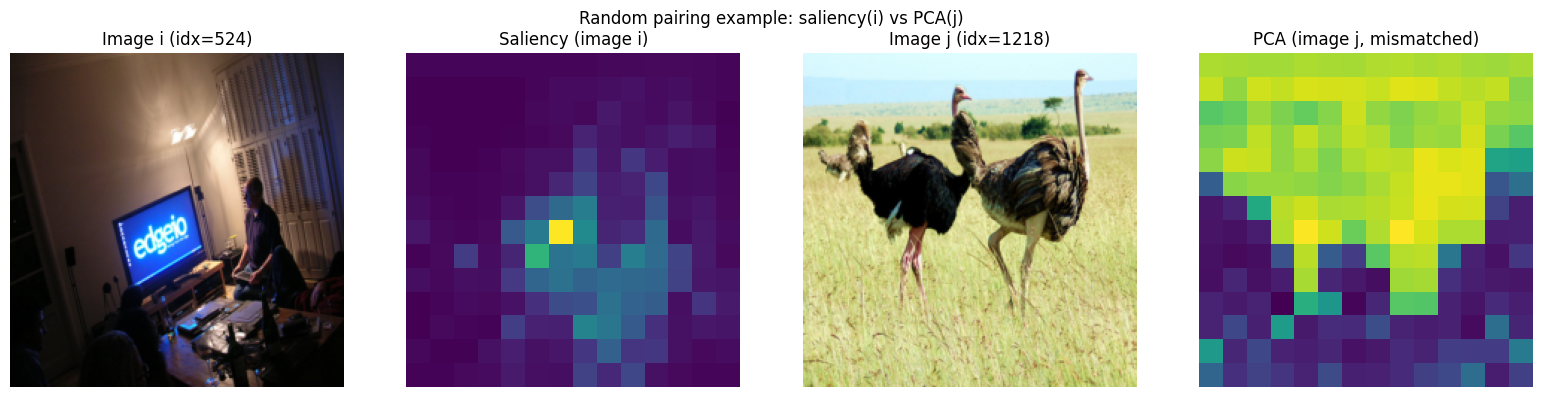

In [ ]:
example_i = 0
example_j = perm[example_i]
img_tensor_i, _ = voc_dataset[indices[example_i]]
img_tensor_j, _ = voc_dataset[indices[example_j]]
img_np_i = denormalize(img_tensor_i)
img_np_j = denormalize(img_tensor_j)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(img_np_i); axes[0].set_title(f"Image i (idx={indices[example_i]})"); axes[0].axis("off")
axes[1].imshow(cached_saliency_norm[example_i], cmap="viridis"); axes[1].set_title("Saliency (image i)"); axes[1].axis("off")
axes[2].imshow(img_np_j); axes[2].set_title(f"Image j (idx={indices[example_j]})"); axes[2].axis("off")
axes[3].imshow(cached_pca[example_j], cmap="viridis"); axes[3].set_title("PCA (image j, mismatched)"); axes[3].axis("off")

plt.suptitle("Random pairing example: saliency(i) vs PCA(j)")
plt.tight_layout()
plt.savefig(SAVE_PATH / "null_test2_example.png", dpi=150)
plt.show()

### 6.6 Null Test 3 - Spatial Patch-Shuffling

Verifies that the observed alignment depends on the correct spatial arrangement of patch representations rather than on their value distribution alone


A complementary control to Null Test 2: instead of replacing the PCA map with one from another image, the spatial arrangement of the same PCA map is shuffled, keeping its value distribution but breaking the correlation between values and their positions. If SAS were only driven by similar value distributions (rather than true spatial correspondence), it would remain unchanged after this shuffle. All three variants drop significantly, confirming that spatial correspondence.


In [ ]:
set_seed(SEED + 3)

spatial_shuffle_results = []
bt_indices = indices

for idx in tqdm(range(len(bt_indices)), desc="Spatial patch-shuffling test"):
    saliency_raw = cached_saliency_raw[idx]
    saliency_norm = cached_saliency_norm[idx]
    pca_norm = cached_pca[idx]

    # create a random permutation of indices from 0 to 195
    patch_perm = np.random.permutation(GRID_SIZE * GRID_SIZE)

    # apply the permutation destroying the spatial structure of the PCA map
    pca_norm_shuffled = pca_norm.flatten()[patch_perm].reshape(GRID_SIZE, GRID_SIZE)

    spatial_shuffle_results.append({
        "sas_corr": sas_corr(saliency_norm, pca_norm_shuffled),
        "sas_dep": sas_dep(saliency_norm, pca_norm_shuffled),
        "sas_loc": sas_loc(saliency_raw, pca_norm_shuffled)
    })


# save
df_spatial_shuffle = pd.DataFrame(spatial_shuffle_results)
print("MEAN SAS COMPARISON - Original Structure vs Spatial Shuffle:")
comparison_shuffle = pd.DataFrame({
    "Original_Model": df_calibration[sas_variants].mean(),
    "Spatial_Shuffle": df_spatial_shuffle[sas_variants].mean()
})
print(comparison_shuffle)

Spatial patch-shuffling test:   0%|          | 0/1449 [00:00<?, ?it/s]

MEAN SAS COMPARISON - Original Structure vs Spatial Shuffle:
          Original_Model  Spatial_Shuffle
sas_corr        0.459021         0.000334
sas_dep         0.555507         0.107160
sas_loc         0.334836         0.178488


#### 6.6.1 Qualitative Example

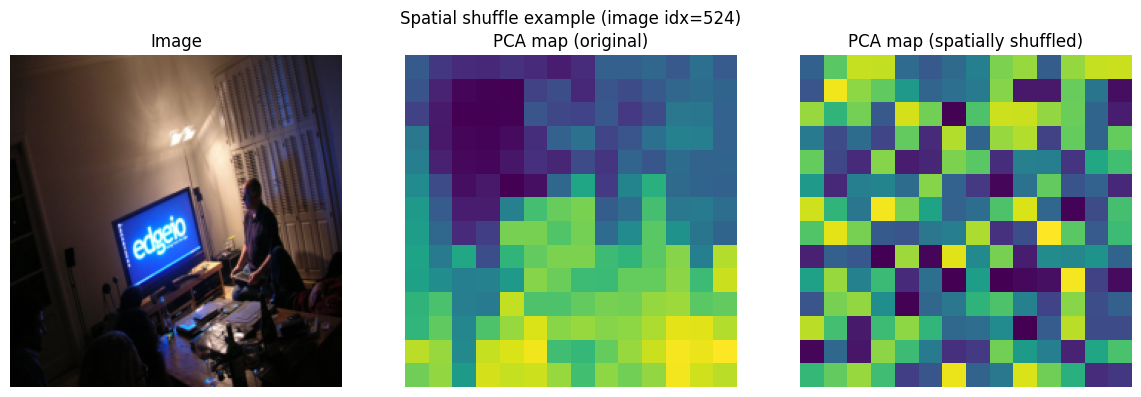

In [ ]:
example_idx = bt_indices[0]
img_tensor, _ = voc_dataset[example_idx]
img_np = denormalize(img_tensor)

pca_before = cached_pca[0]  # bt_indices[0] == indices[0]
patch_perm_example = np.random.permutation(GRID_SIZE * GRID_SIZE)
pca_after = pca_before.flatten()[patch_perm_example].reshape(GRID_SIZE, GRID_SIZE)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img_np); axes[0].set_title("Image"); axes[0].axis("off")
axes[1].imshow(pca_before, cmap="viridis"); axes[1].set_title("PCA map (original)"); axes[1].axis("off")
axes[2].imshow(pca_after, cmap="viridis"); axes[2].set_title("PCA map (spatially shuffled)"); axes[2].axis("off")

plt.suptitle(f"Spatial shuffle example (image idx={example_idx})")
plt.tight_layout()
plt.savefig(SAVE_PATH / "null_test3_example.png", dpi=150)
plt.show()

**Results**: all three SAS variants correlate significantly with ground-truth IoU. However, `sas_dep` (distance correlation), the metric least sensitive to that sign bug, and the top performer in raw correlation, is also the only one that fails the random-weights null test, consistently across four independent random seeds (Section 6.4.3). `sas_corr` and `sas_loc` pass every check. This trade-off is reported explicitly, rather than simply choosing the single metric with the highest correlation.